<a href="https://colab.research.google.com/github/onlyforstudy7770-cpu/DeepFake-voice-detection-project/blob/log_reg/ASVsfooping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")


100%|██████████| 23.6G/23.6G [03:26<00:00, 122MB/s]

Extracting files...


KeyboardInterrupt: 

In [4]:
path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1"

In [3]:

print("Path to dataset files:", path)

NameError: name 'path' is not defined

(128, 73)


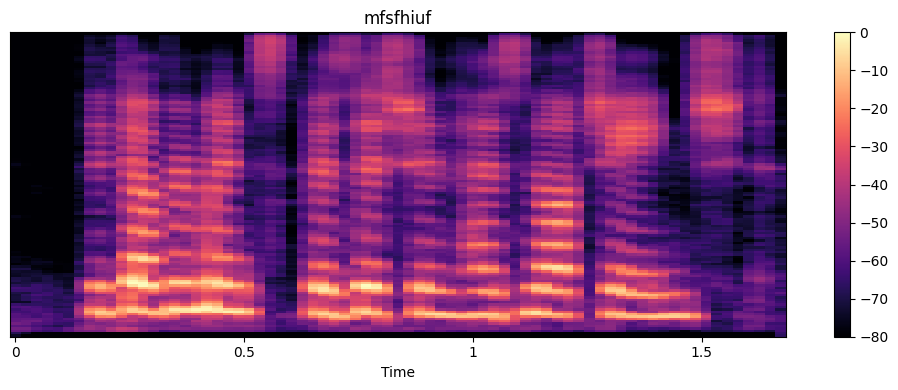

In [ ]:

y , src =  librosa.load(path+"/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1001718.flac" , sr = 16000)

mfcc = librosa.feature.mfcc( y = y , sr = src , n_mfcc= 13)
S = librosa.feature.melspectrogram(y = y, sr = src, n_mels = 128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)


print(S_dB.shape)
plt.figure(figsize = (10 , 4))
librosa.display.specshow( S_dB , x_axis= 'time')
plt.colorbar()
plt.title("mfsfhiuf")
plt.tight_layout()
plt.show()


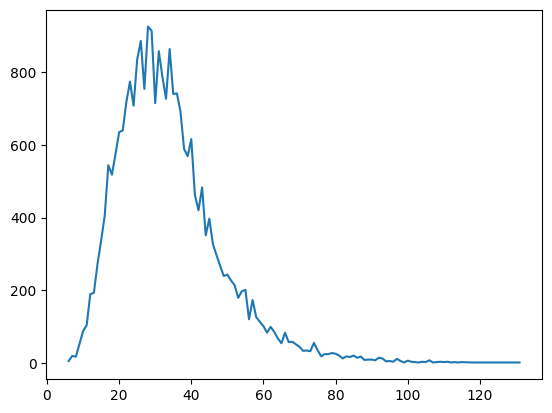

2.8 - 926


In [ ]:
file_name = os.listdir(path+"/LA/LA/ASVspoof2019_LA_train/flac")

dc ={}
for file in file_name:
  # y , src =  librosa.load(path +"/LA/LA/ASVspoof2019_LA_train/flac/" + file , sr = 16000)
  y = librosa.get_duration( path = path +"/LA/LA/ASVspoof2019_LA_train/flac/" + file)
  y = int ( y*10)
  if (y not in dc):
    dc[y] = 1
  else:
    dc[y] += 1


sorted_data = sorted(dc.items())
x, y = zip(*sorted_data)
plt.plot(x, y)
plt.show()

max = 0
l = 0

for i in range ( 0 , len(x)):
  if y[i] > max :
    max = y[i]
    l = x[i]
print ( l/10 , "-" , max)






filename = file.flac / system_id == A0 , A1 , A2 etc / target == 0 (real) , 1 (sfooped)

In [ ]:
import pandas as pd

file = ("train.trn" , "eval.trl" , "dev.trl")
# os.makedirs("/AA" , exist_ok = True)

for res in file:

  data_dec = {"filename" : [],
        "system_id":[],
        "target" : []}

  with open ( path+f"/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.{res}.txt" , 'r') as train:
    for line in train:

      data = line.strip().split()

      if (data[4] == "bonafide"):
          data_dec["filename"].append(data[1])
          data_dec["system_id"].append('-')
          data_dec["target"].append(0)

      else:

          data_dec["filename"].append(data[1])
          data_dec["target"].append(1)
          data_dec["system_id"].append(data[3])

  df = pd.DataFrame(data_dec)
  df.to_csv(f"/content/drive/MyDrive/ASVsfoop_data/{res}.csv" , index = False)



In [ ]:
size = 6000
audio_sample_size = 4
# fil = ("train" , "eval" , "dev")
fil = ("train" , "eval" )
# os.makedirs("/AA" , exist_ok = True)
for fi in fil:
  i = 0
  file_name = os.listdir(path+f"/LA/LA/ASVspoof2019_LA_{fi}/flac")

  os.makedirs(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_mfcc" , exist_ok = True)
  os.makedirs(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_s_db" , exist_ok = True)

  for file in file_name:
    y , src =  librosa.load(path+f"/LA/LA/ASVspoof2019_LA_{fi}/flac/"+ file , sr = 16000)
    temp = int(audio_sample_size * src)

    if ( len(y) > temp):
      y = y[0:temp]
    elif ( len(y) <temp):
      y = np.pad(y , (0 ,temp-len(y)) , mode= 'constant')

    mfcc = librosa.feature.mfcc( y = y , sr = src , n_mfcc= 40)
    S = librosa.feature.melspectrogram(y = y, sr = src, n_mels = 128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)

    np.save(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_mfcc/{file}" , mfcc)
    np.save(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_s_db/{file}" , S_dB)

    i +=1
    if ( ( i / 100) % 1 == 0):
      print("\r" ,i ,"/",size, end ="")
    if ( i >= size):
      break
  print()

 6000 / 6000
 6000 / 6000


In [ ]:

folder = os.listdir(f"/AA/train_mfcc")
i = 0
for file in folder:
  data = np.load(f"/AA/train_mfcc/{file}").ravel()
  i+=1
  if (len(data) != 5040 ):
    print(len(data))
    print(file)
    break
print (i)



100


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [6]:
X_train = []
y_train = []


res = ("train" , "eval" , "dev")


df = pd.read_csv("/content/drive/MyDrive/ASVsfoop_data/train.trn.csv")

target_map = dict(zip(df["filename"], df["target"]))

folder_path = "/content/drive/MyDrive/ASVsfoop_data/train_mfcc"
folder = os.listdir(folder_path)

for file in folder:
  csv_filename = file.replace(".flac.npy" , "")

  data = np.load(os.path.join(folder_path, file)).ravel()
  X_train.append(data)
  y_train.append(int(target_map[csv_filename]))


In [8]:

X_test = []
y_test = []

res = ("train" , "eval" , "dev")


df = pd.read_csv("/content/drive/MyDrive/ASVsfoop_data/eval.trl.csv")

target_map = dict(zip(df["filename"], df["target"]))

folder_path = "/content/drive/MyDrive/ASVsfoop_data/eval_mfcc"
folder = os.listdir(folder_path)

for file in folder:
  csv_filename = file.replace(".flac.npy" , "")
  if (target_map.get(csv_filename) is None):
    continue

  data = np.load(os.path.join(folder_path, file)).ravel()
  X_test.append(data)
  y_test.append(int(target_map[csv_filename]))


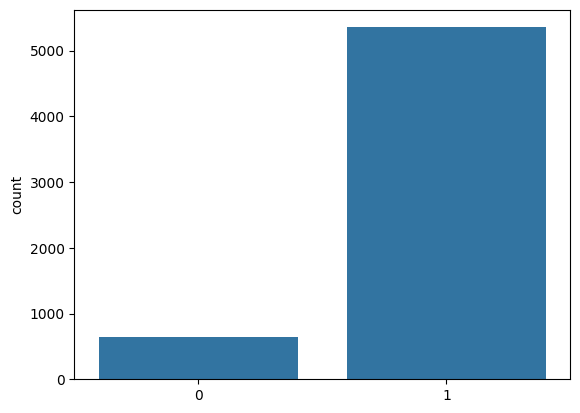

In [33]:
sns.countplot(x = y_train)
plt.show()

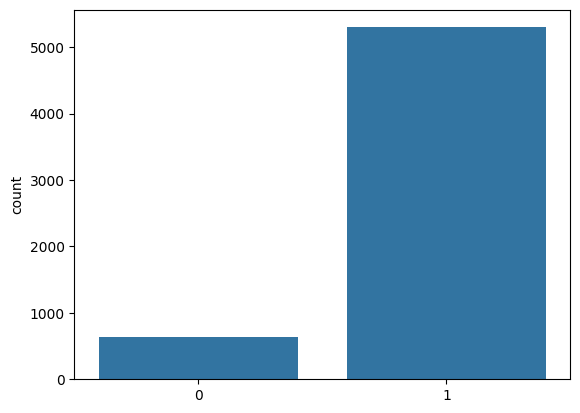

In [51]:
sns.countplot(x = y_test)
plt.show()

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [55]:
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=100 ))
pipeline.fit(X_train , y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [56]:
pipeline.score(X_train , y_train)

1.0

In [57]:
print(len(y_test))

5933


In [58]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
y_pred = pipeline.predict(X_test)

In [59]:
from sklearn.metrics import  confusion_matrix , classification_report
print (confusion_matrix(y_test , y_pred))

[[ 549   83]
 [ 906 4395]]


In [60]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.38      0.87      0.53       632
           1       0.98      0.83      0.90      5301

    accuracy                           0.83      5933
   macro avg       0.68      0.85      0.71      5933
weighted avg       0.92      0.83      0.86      5933



In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns     #graphing
from sklearn.linear_model import LinearRegression

In [ ]:
np.random.seed(42)
num_sample = 500000
year_of_expreance = np.random.randint(2, 21 , size = num_sample)

slope = (200_000 - 60_000) /18
intercept = 60_000

salary = slope * year_of_expreance + intercept + np.random.normal( 0 , 10_000 , size = num_sample)

data = {"year_of_expreance" : year_of_expreance , "salary" : salary}

df = pd.DataFrame(data)

In [ ]:
df.describe()

,year_of_expreance,salary
count,500000.000000,500000.000000
mean,11.004812,145587.929558
std,5.481684,43793.775390
min,2.000000,31967.692665
25%,6.000000,108571.318270
50%,11.000000,145603.604446
75%,16.000000,182662.711346
max,20.000000,258981.859937


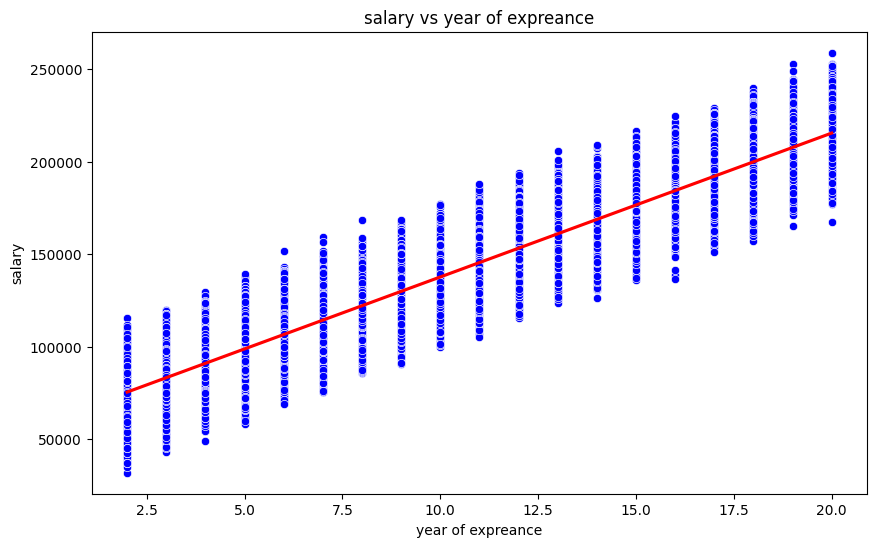

In [ ]:
# from IPython.core.magics.script import script_args
plt.figure(figsize = (10 , 6))
sns.scatterplot ( x= "year_of_expreance" , y = "salary" , data = df , color = "blue")
sns.regplot(x = "year_of_expreance" , y = "salary" , data = df , color="red" , scatter = False)
plt.xlabel("year of expreance")
plt.ylabel("salary")
plt.title("salary vs year of expreance")
plt.show()

In [ ]:
x= df[["year_of_expreance"]]
y = df["salary"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


In [ ]:
lr = LinearRegression()
lr.fit(X_train , y_train)

In [ ]:
lr.score(X_train , y_train)

In [ ]:
lr.score(X_test , y_test)

In [ ]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [ ]:
y_pried = lr.predict(X_test)

In [ ]:
mean_absolute_error(y_test , y_pried)

8002.943049937687

In [ ]:
mean_squared_error(y_test , y_pried)


100354371.58273928

In [ ]:
r2_score(y_test , y_pried)


0.9478792981516551

In [ ]:
lr.coef_

array([7776.52478413])

In [ ]:
lr.intercept_

np.float64(60011.37161103982)

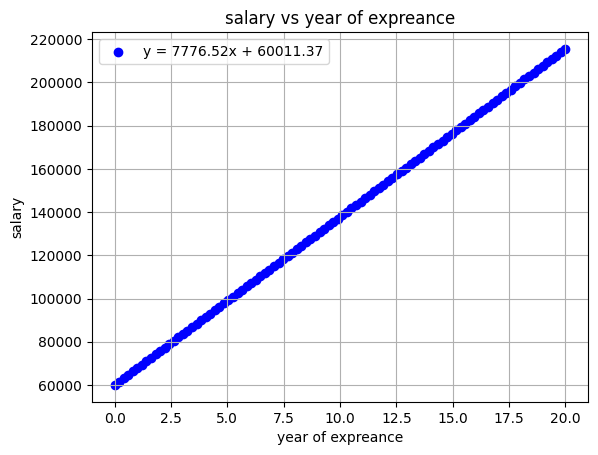

In [ ]:
coefficients = lr.coef_
intercept = lr.intercept_
x = np.linspace( 0, 20 , 100)
y = coefficients * x + intercept
plt.scatter(x , y  , label = f"y = {coefficients[0]:.2f}x + {intercept:.2f}" , color= "blue")
plt.xlabel("year of expreance")
plt.ylabel("salary")
plt.title("salary vs year of expreance")
plt.legend()
plt.grid()
plt.show()


multi regression



In [ ]:
import pandas as pd
import numpy as np
import random

In [ ]:
data = []
sample_count = 500
for _ in range( sample_count):
  team_name = f"Team{chr(random.randint(65 , 90))}"
  season = random.randint(2010 , 2025)
  wins= random.randint(50 , 110)
  losses = 162 - wins
  hits = random.randint(1200 , 1600)
  doubles = random.randint(200 , 350)
  triples = random.randint(10 , 50)
  home_runs = random.randint( 100, 200)
  strikeout = random.randint(1000, 1500)

  hit_adjusted = hits + (wins - 80 ) *5
  doubles_adjusted = doubles + (wins - 80) * 2
  triples_adjusted = triples + (wins - 80) * 1
  home_runs_adjusted = home_runs + (wins - 80)*3
  strikeout_adjusted = strikeout - (wins - 80)*10


  data.append([team_name , season  , wins , losses , hit_adjusted , doubles_adjusted , triples_adjusted , home_runs_adjusted , strikeout_adjusted])


In [ ]:
colums = ["team" , "season" , "wins", "loses" , "hits", "doubles", "triples" , "holerun" , "strikeout"]

In [ ]:
df = pd.DataFrame(data , columns = colums)
df.head()

,team,season,wins,loses,hits,doubles,triples,holerun,strikeout
0,TeamC,2022,107,55,1467,297,53,198,1172
1,TeamI,2024,77,85,1284,281,31,127,1223
2,TeamF,2015,102,60,1405,249,33,225,784
3,TeamF,2019,86,76,1581,277,20,124,1253
4,TeamF,2022,64,98,1338,217,2,69,1294


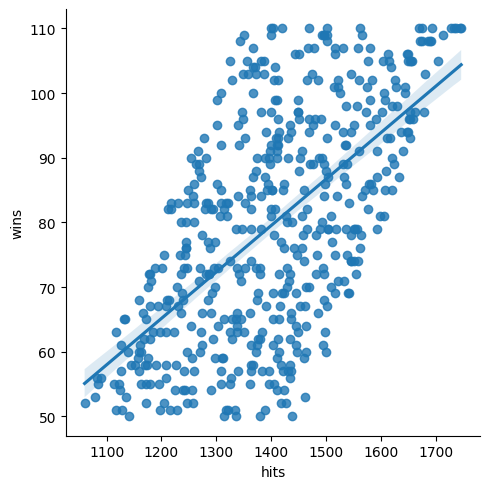

In [ ]:
sns.lmplot(x= "hits", y ="wins" , data = df)
plt.show()

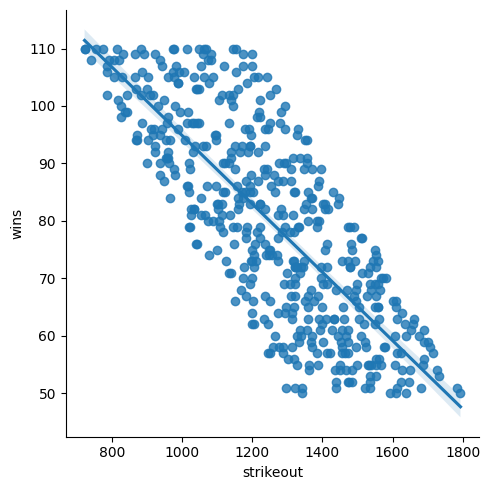

In [ ]:
sns.lmplot ( x = "strikeout" , y = "wins" , data = df)
plt.show()

In [ ]:
df2 = df.drop(columns = ["team" , "season" , "loses"] , axis = 1)

In [ ]:
df2.head()


,wins,hits,doubles,triples,holerun,strikeout
0,107,1467,297,53,198,1172
1,77,1284,281,31,127,1223
2,102,1405,249,33,225,784
3,86,1581,277,20,124,1253
4,64,1338,217,2,69,1294


In [ ]:
df2.columns

Index(['wins', 'hits', 'doubles', 'triples', 'holerun', 'strikeout'], dtype='object')

In [ ]:
x = df[['hits', 'doubles', 'triples', 'holerun', 'strikeout']]
y  =df["wins"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 30)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train , y_train)

LinearRegression()

In [ ]:
lr.score(X_test, y_test)

0.8573054768898707

In [ ]:
lr.score(X_train , y_train)

0.8966243484596811

In [ ]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [ ]:
y_predict = lr.predict(X_test)


In [ ]:
mean_absolute_error(y_test , y_predict)

5.174928526833334

In [ ]:
mean_squared_error(y_test , y_predict)

39.34550332401142

In [ ]:
r2_score(y_test , y_predict)

0.8573054768898707

In [ ]:
lr.coef_


array([ 0.0120093 ,  0.02928896,  0.2419525 ,  0.11630273, -0.01709814])

In [ ]:
lr.intercept_

np.float64(51.03450059723308)

logestic regression


equation of lesgtic equition y = (1/(1 + e^-1*(mX + b)))

In [ ]:
import pandas as pd
d = {'miles_per_week': [37,39,46,51,88,17,18,20,21,22,23,24,25,27,28,29,30,31,32,33,34,38,40,42,57,68,35,36,41,43,45,47,49,50,52,53,54,55,56,58,59,60,61,63,64,65,66,69,70,72,73,75,76,77,78,80,81,82,83,84,85,86,87,89,91,92,93,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,113,114,115,116,116,118,119,120,121,123,124,126,62,67,74,79,90,112],
      'completed_50m_ultra': ['no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','yes','yes','yes','yes','no','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes',]}

df = pd.DataFrame(d)
df

,miles_per_week,completed_50m_ultra
0,37,no
1,39,no
2,46,no
3,51,no
4,88,no
...,...,...
96,67,yes
97,74,yes
98,79,yes
99,90,yes


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
finished_race = ["no", "yes"]

enc = OrdinalEncoder(categories = [finished_race])
df[["completed_50m_ultra"]] = enc.fit_transform(df[["completed_50m_ultra"]] )

In [ ]:
df

,miles_per_week,completed_50m_ultra
0,37,0.0
1,39,0.0
2,46,0.0
3,51,0.0
4,88,0.0
...,...,...
96,67,1.0
97,74,1.0
98,79,1.0
99,90,1.0


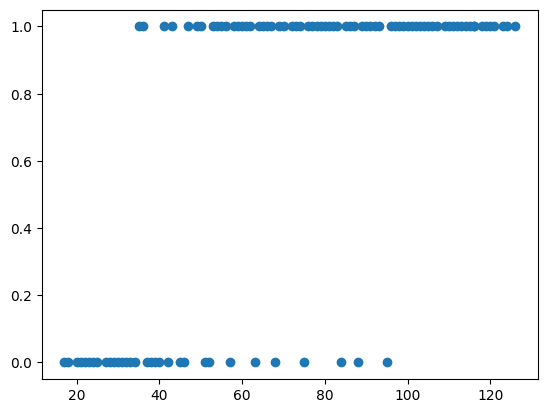

In [ ]:
plt.scatter( x = "miles_per_week" , y = "completed_50m_ultra" , data = df)
plt.show()

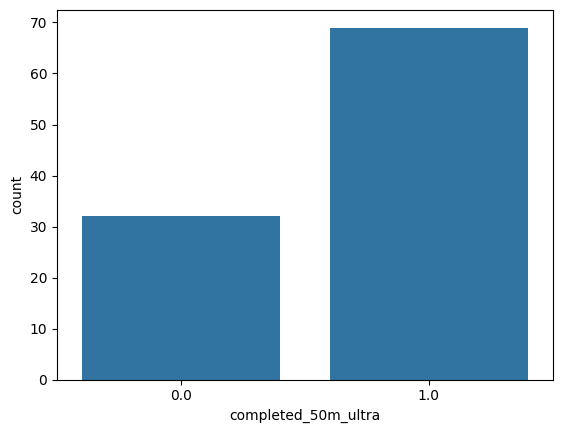

In [ ]:
sns.countplot(x = "completed_50m_ultra" , data = df)
plt.show()

In [ ]:
x = df[["miles_per_week"]]
y = df["completed_50m_ultra" ]

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 11)

In [ ]:
X_train.shape

(80, 1)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train , y_train)

LogisticRegression()

In [ ]:
lr.score(X_train , y_train)

0.825

In [ ]:
lr.score(X_test , y_test)

0.9047619047619048

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import  confusion_matrix , classification_report

In [ ]:
print (confusion_matrix(y_test , y_pred))

[[ 5  1]
 [ 1 14]]


In [ ]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.93      0.93      0.93        15

    accuracy                           0.90        21
   macro avg       0.88      0.88      0.88        21
weighted avg       0.90      0.90      0.90        21

